In [ ]:
from transformers_sae.ops import load_checkpoint

loss_history = {}
min_layer = 0
max_layer = 8
# num_tokens = 10000585
# num_tokens = 5001006
num_tokens = 2000682
# num_tokens = 1000660
variant = "_tmse"
for layer in range(min_layer, max_layer + 1):
    loss_history[layer] = load_checkpoint(
        f"/workspace/sae_checkpoints/gemma_2_2b/next_layer_lista_onsager_tuned_encoder_0{variant}/layer_{layer}_tokens_{num_tokens}.checkpoint",
    ).step_metrics["loss"]

FileNotFoundError: [Errno 2] No such file or directory: '/workspace/sae_checkpoints/gemma_2_2b/next_layer_lista_onsager_tuned_encoder_0_tmse/layer_0_tokens_1000660.checkpoint'

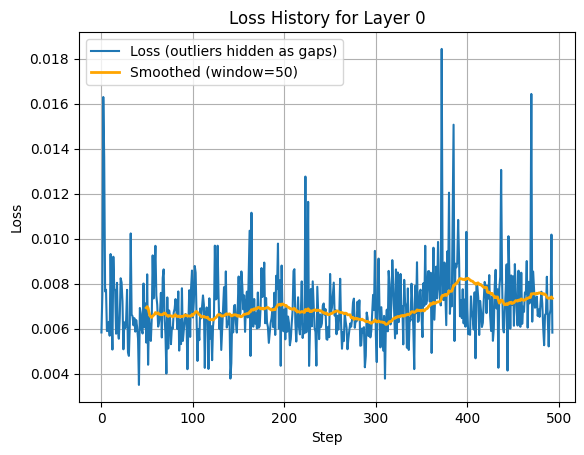

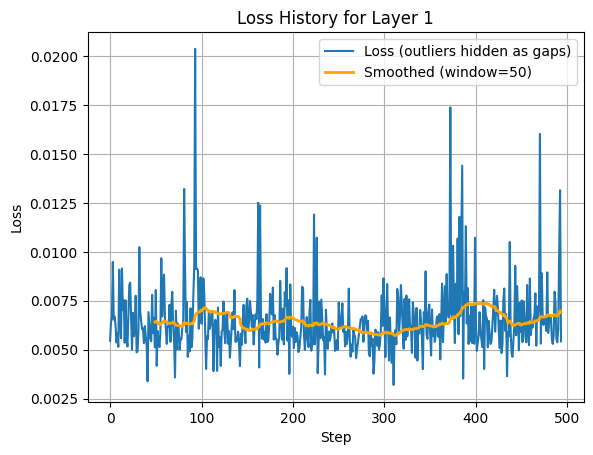

In [82]:
import matplotlib.pyplot as plt
import numpy as np

window_size = 50  # set the window size for smoothing, tweak as preferred

for layer, losses in loss_history.items():
    losses = np.array(losses)
    cutoff = np.percentile(losses, 95)
    # Create a new array where outliers above the cutoff are set to np.nan,
    # which will render as gaps in matplotlib plots
    losses_with_gaps = losses.copy()
    # losses_with_gaps[losses > cutoff] = np.nan

    plt.figure()
    plt.plot(losses_with_gaps, label="Loss (outliers hidden as gaps)")

    # For smoothing, use only points that are not nan
    if np.count_nonzero(~np.isnan(losses_with_gaps)) >= window_size:
        # Since np.convolve does not natively handle nans, 
        # use np.lib.stride_tricks/sliding_window_view and nanmean for rolling smoothing with gaps
        from numpy.lib.stride_tricks import sliding_window_view

        valid_mask = ~np.isnan(losses_with_gaps)
        smoothed = []
        xvals = []
        # # Compute windowed nanmean, skip windows that are all-nan
        # for i in range(window_size - 1, len(losses_with_gaps)):
        #     window = losses_with_gaps[i - window_size + 1:i + 1]
        #     if np.all(np.isnan(window)):
        #         smoothed.append(np.nan)
        #     else:
        #         smoothed.append(np.nanmean(window))
        #     xvals.append(i)
        # plt.plot(
        #     xvals,
        #     smoothed,
        #     label=f"Smoothed (window={window_size})",
        #     color="orange",
        #     linewidth=2,
        # )
        for i in range(window_size - 1, len(losses)):
            window = losses[i - window_size + 1:i + 1]
            smoothed.append(np.mean(window))
            xvals.append(i)
        plt.plot(
            xvals,
            smoothed,
            label=f"Smoothed (window={window_size})",
            color="orange",
            linewidth=2,
        )

    plt.title(f"Loss History for Layer {layer}")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

# From scratch

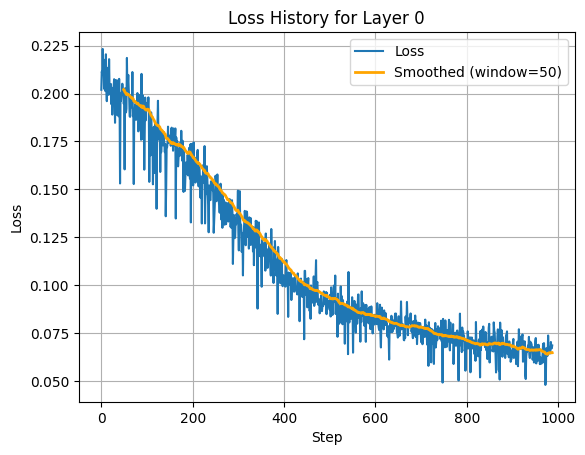

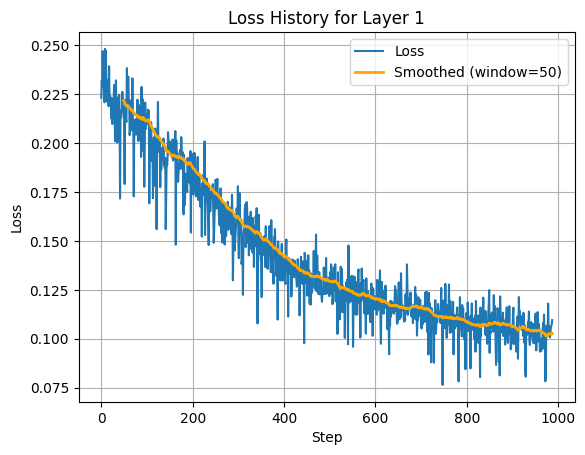

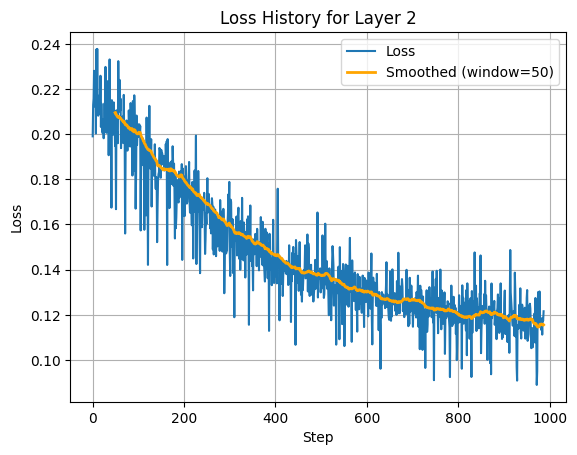

In [2]:
import matplotlib.pyplot as plt
import numpy as np

window_size = 50  # set the window size for smoothing, tweak as preferred

for layer, losses in loss_history.items():
    plt.figure()
    plt.plot(losses, label="Loss")

    if len(losses) >= window_size:
        # Compute moving average
        smoothed = np.convolve(losses, np.ones(window_size)/window_size, mode='valid')
        plt.plot(
            np.arange(window_size - 1, len(losses)),
            smoothed,
            label=f"Smoothed (window={window_size})",
            color="orange",
            linewidth=2,
        )

    plt.title(f"Loss History for Layer {layer}")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.show()